<a href="https://colab.research.google.com/github/emilyteixeira/emilys-cv-journey/blob/main/vis101_t2_transformacoes_geometricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

Seguindo a sequência, agora transformamos a **geometria** da imagem: mudar o
tamanho, deslocar, girar e espelhar. Essas operações reaparecem o tempo todo em visão
computacional, do aumento de dados ao alinhamento de imagens.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (5, 4), 'font.size': 12})
print('Setup pronto.')

Setup pronto.


In [ ]:
img = cv2.imread("data/carlos.jpg")
print("forma original:", img.shape)

forma original: (915, 915, 3)


## Redimensionar

A função `cv2.resize` muda o tamanho da imagem. Podemos passar um tamanho de destino em
pixels ou um fator de escala.

nova forma: (200, 200, 3)


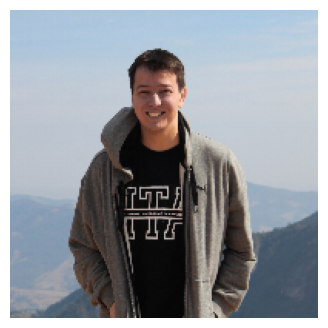

In [ ]:
pequena = cv2.resize(img, (200, 200))
print("nova forma:", pequena.shape)

plt.imshow(pequena[:, :, ::-1])
plt.axis("off")
plt.show()

In [ ]:
metade = cv2.resize(img, None, fx=0.5, fy=0.5)
print("pela metade:", metade.shape)

pela metade: (458, 458, 3)


## Transladar

Transladar é deslocar a imagem no plano. Montamos uma matriz de translação com os
deslocamentos em x e y, e aplicamos com `cv2.warpAffine`.

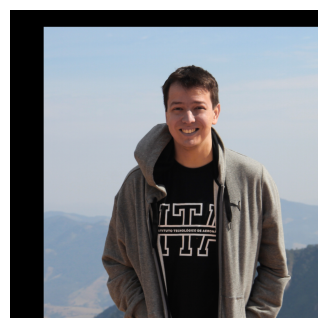

In [ ]:
h, w = img.shape[:2]
M = np.float32([[1, 0, 100], [0, 1, 50]])   # desloca 100 em x e 50 em y
deslocada = cv2.warpAffine(img, M, (w, h))

plt.imshow(deslocada[:, :, ::-1])
plt.axis("off")
plt.show()

## Rotacionar

Para girar, criamos a matriz de rotação com `cv2.getRotationMatrix2D`, informando o
centro, o ângulo e a escala, e aplicamos também com `warpAffine`.

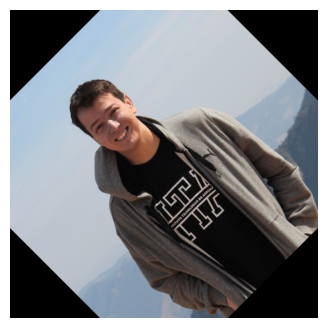

In [ ]:
M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1.0)   # 45 graus, escala 1
rotacionada = cv2.warpAffine(img, M, (w, h))

plt.imshow(rotacionada[:, :, ::-1])
plt.axis("off")
plt.show()

## Espelhar

O espelhamento inverte a imagem. Com `cv2.flip`, o código 1 espelha na horizontal, 0 na
vertical.

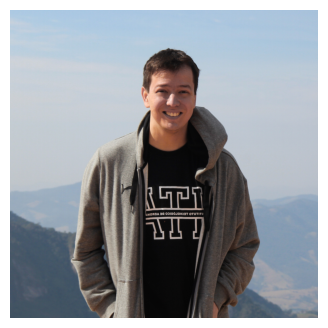

In [ ]:
espelhada = cv2.flip(img, 1)

plt.imshow(espelhada[:, :, ::-1])
plt.axis("off")
plt.show()

## Síntese

Redimensionar usa `cv2.resize`. Transladar e rotacionar usam uma matriz de transformação
aplicada por `cv2.warpAffine`. Espelhar usa `cv2.flip`. Todas operam sobre a mesma ideia:
reposicionar os pixels segundo uma regra geométrica.